In [ ]:
from google.colab import files
uploaded = files.upload()

Saving drive-download-20260327T092807Z-1-001.zip to drive-download-20260327T092807Z-1-001.zip


In [ ]:
import zipfile
import os

zip_filename = list(uploaded.keys())[0]

extract_path = "data"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))

Extracted files: ['march_first_half.csv', 'june_sec_half.csv', 'march_sec_half.csv', 'april_sec_half.csv', 'may_first_half.csv', 'feb_first_half.csv', 'april_first_half.csv', 'jan_first_half.csv', 'feb_sec_half.csv', 'june_first_half.csv', 'jan_sec_half.csv']


In [ ]:
import zipfile
import os

zip_filename = list(uploaded.keys())[0]

extract_path = "data"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))

Extracted files: ['march_first_half.csv', 'june_sec_half.csv', 'march_sec_half.csv', 'april_sec_half.csv', 'may_first_half.csv', 'feb_first_half.csv', 'april_first_half.csv', 'jan_first_half.csv', 'feb_sec_half.csv', 'june_first_half.csv', 'jan_sec_half.csv']


In [ ]:
import pandas as pd

import glob

files = glob.glob("*.csv")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df.head()

,date,amount,emp_id,vendor,category,department
0,2024-05-16,3709,FIN0001,MakeMyTrip,Office,Finance
1,2024-05-16,972,FIN0002,MakeMyTrip,Travel,Finance
2,2024-05-16,1863,FIN0003,Flipkart,Software,Finance
3,2024-05-16,504,FIN0004,Swiggy,Travel,Finance
4,2024-05-16,3727,FIN0005,Flipkart,Software,Finance


In [ ]:

df.tail()

,date,amount,emp_id,vendor,category,department
3195,2024-05-31,493,OPS0046,Uber,Office,Operations
3196,2024-05-31,1430,OPS0047,Swiggy,Travel,Operations
3197,2024-05-31,2357,OPS0048,Flipkart,Electronics,Operations
3198,2024-05-31,3174,OPS0049,Flipkart,Travel,Operations
3199,2024-05-31,3485,OPS0050,Swiggy,Software,Operations


In [ ]:
df.columns = df.columns.str.strip()

df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

df = df.dropna(subset=['amount'])

In [ ]:
# Employee average spending
avg_amount = df.groupby('emp_id')['amount'].mean()

# Frequency
freq = df.groupby('emp_id').size()

# Vendor frequency
vendor_freq = df.groupby(['emp_id', 'vendor']).size()

df['avg_amount'] = df['emp_id'].map(avg_amount)
df['frequency'] = df['emp_id'].map(freq)

df['vendor_freq'] = df.set_index(['emp_id', 'vendor']).index.map(vendor_freq)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['day_of_week'] = df['date'].dt.dayofweek

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_vendor = LabelEncoder()
le_category = LabelEncoder()
le_department = LabelEncoder()
le_emp = LabelEncoder()

df['vendor'] = le_vendor.fit_transform(df['vendor'])
df['category'] = le_category.fit_transform(df['category'])
df['department'] = le_department.fit_transform(df['department'])
df['emp_id'] = le_emp.fit_transform(df['emp_id'])

In [ ]:
features = [
    'amount',
    'avg_amount',
    'frequency',
    'vendor_freq',
    'day_of_week',
    'vendor',
    'category',
    'department'
]

X = df[features]

In [ ]:
X

,amount,avg_amount,frequency,vendor_freq,day_of_week,vendor,category,department
0,3709,2327.0625,16,1,3,2,2,0
1,972,2031.2500,16,5,3,2,4,0
2,1863,2279.7500,16,3,3,1,3,0
3,504,12803.1250,16,5,3,3,4,0
4,3727,1825.0000,16,6,3,1,3,0
...,...,...,...,...,...,...,...,...
3195,493,1778.0625,16,5,4,4,2,3
3196,1430,10869.7500,16,4,4,3,4,3
3197,2357,5260.9375,16,4,4,1,0,3
3198,3174,8598.0625,16,3,4,1,4,3


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [ ]:
df['anomaly'] = model.predict(X_scaled)

df['anomaly'] = df['anomaly'].map({1:0, -1:1})

In [ ]:
df['risk_score'] = model.decision_function(X_scaled)

In [ ]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_vendor, "le_vendor.pkl")
joblib.dump(le_category, "le_category.pkl")
joblib.dump(le_department, "le_department.pkl")
joblib.dump(le_emp, "le_emp.pkl")

['le_emp.pkl']

#Testing phase

In [ ]:
df['train_pred'] = model.predict(X_scaled)
df['train_pred'] = df['train_pred'].map({1: "Normal", -1: "Fraud"})

df['train_pred'].value_counts()

,count
train_pred,
Normal,3040
Fraud,160


In [ ]:
df['score'] = model.decision_function(X_scaled)

df['score'].describe()

,score
count,3200.000000
mean,0.082231
std,0.042409
min,-0.122580
25%,0.063600
50%,0.088628
75%,0.110547
max,0.163922


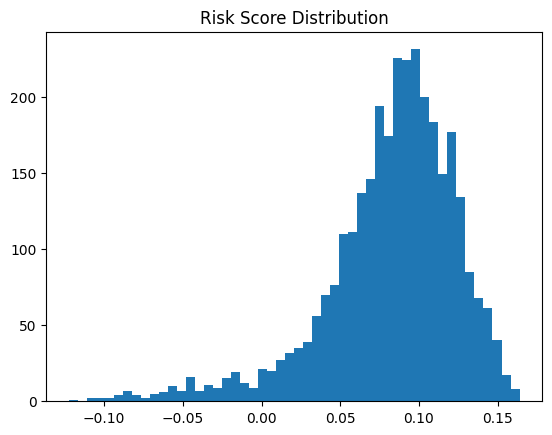

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['score'], bins=50)
plt.title("Risk Score Distribution")
plt.show()

In [ ]:
df[features].describe()

,amount,avg_amount,frequency,vendor_freq,day_of_week,vendor,category,department
count,3200.000000,3200.000000,3200.0,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,7940.105938,7940.105938,16.0,4.005625,3.062500,1.986250,1.992188,1.500000
std,27090.909932,6661.312860,0.0,1.544576,1.886718,1.390518,1.406545,1.118209
min,200.000000,1572.250000,16.0,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1229.000000,2245.812500,16.0,3.000000,1.750000,1.000000,1.000000,0.750000
50%,2195.500000,5776.343750,16.0,4.000000,3.000000,2.000000,2.000000,1.500000
75%,3255.500000,12479.156250,16.0,5.000000,4.250000,3.000000,3.000000,2.250000
max,198670.000000,35744.000000,16.0,9.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
X_scaled.mean(axis=0)
X_scaled.std(axis=0)

array([1., 1., 0., 1., 1., 1., 1., 1.])

#Test

In [ ]:
# ============================
# 1. Upload File
# ============================
from google.colab import files
import pandas as pd
import numpy as np
import joblib

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Load file
if file_name.endswith('.csv'):
    test_df = pd.read_csv(file_name)
else:
    test_df = pd.read_excel(file_name)

# ============================
# 2. Normalize column names
# ============================
test_df.columns = test_df.columns.str.strip().str.lower()

# Force consistent naming
test_df.rename(columns={
    'emp id': 'emp_id',
    'employee_id': 'emp_id'
}, inplace=True)

# ============================
# 3. Load Model + Tools
# ============================
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

le_vendor = joblib.load("le_vendor.pkl")
le_category = joblib.load("le_category.pkl")
le_department = joblib.load("le_department.pkl")
le_emp = joblib.load("le_emp.pkl")

# ============================
# 4. Clean Data
# ============================
test_df['amount'] = test_df['amount'].replace('[₹,]', '', regex=True)
test_df['amount'] = pd.to_numeric(test_df['amount'], errors='coerce')
test_df = test_df.dropna(subset=['amount'])

test_df['date'] = pd.to_datetime(test_df['date'], errors='coerce')
test_df['day_of_week'] = test_df['date'].dt.dayofweek

# ============================
# 5. Load Training History (FIXED)
# ============================
history_df = df.copy()

# Normalize history columns too
history_df.columns = history_df.columns.str.strip().str.lower()

# ============================
# 6. Feature Engineering (FIXED COLUMN NAMES)
# ============================
avg_amount_map = history_df.groupby('emp_id')['amount'].mean()
freq_map = history_df.groupby('emp_id').size()
vendor_freq_map = history_df.groupby(['emp_id','vendor']).size()

test_df['avg_amount'] = test_df['emp_id'].map(avg_amount_map)
test_df['frequency'] = test_df['emp_id'].map(freq_map)

test_df['vendor_freq'] = test_df.set_index(['emp_id','vendor']).index.map(vendor_freq_map)

# Fix missing
test_df['avg_amount'].fillna(test_df['amount'], inplace=True)
test_df['frequency'].fillna(1, inplace=True)
test_df['vendor_freq'].fillna(1, inplace=True)

# ============================
# 7. Encoding (SAFE)
# ============================
def safe_transform(le, series):
    mapping = {label: idx for idx, label in enumerate(le.classes_)}
    return series.map(lambda x: mapping.get(x, 0))

test_df['vendor'] = safe_transform(le_vendor, test_df['vendor'])
test_df['category'] = safe_transform(le_category, test_df['category'])
test_df['department'] = safe_transform(le_department, test_df['department'])
test_df['emp_id'] = safe_transform(le_emp, test_df['emp_id'])

# ============================
# 8. Prepare Features
# ============================
features = [
    'amount',
    'avg_amount',
    'frequency',
    'vendor_freq',
    'day_of_week',
    'vendor',
    'category',
    'department'
]

X_test = test_df[features].fillna(0)

# ============================
# 9. Predict
# ============================
X_scaled = scaler.transform(X_test)

test_df['risk_score'] = model.decision_function(X_scaled)

test_df['prediction'] = test_df['risk_score'].apply(
    lambda x: "Fraud" if x < -0.05 else "Normal"
)

# ============================
# 🔥 10. FINAL OUTPUT (ONLY FRAUD)
# ============================
fraud_df = test_df[test_df['prediction'] == "Fraud"]

fraud_df[['emp_id','amount','risk_score']]

Saving Test.xlsx to Test (2).xlsx


/tmp/ipykernel_2377/3361083230.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['avg_amount'].fillna(test_df['amount'], inplace=True)
/tmp/ipykernel_2377/3361083230.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

,emp_id,amount,risk_score
14,14,646949,-0.138390
19,19,271509,-0.130130
28,28,26588,-0.075957
36,36,429315,-0.137836
47,47,192882,-0.126331
54,53,446247,-0.137836
74,73,748877,-0.138390
87,86,930206,-0.126028
89,88,194568,-0.142172
112,111,571687,-0.143401


In [ ]:
test_df.head()

,date,amount,emp_id,vendor,category,department,day_of_week,avg_amount,frequency,vendor_freq,risk_score,prediction
0,2024-01-28,216,0,0,0,0,6,216.0,1.0,1.0,-0.006447,Normal
1,2024-02-11,81,1,0,0,0,6,81.0,1.0,1.0,-0.006447,Normal
2,2024-02-05,1418,2,0,0,0,0,1418.0,1.0,1.0,0.008969,Normal
3,2024-02-27,3520,3,0,0,0,1,3520.0,1.0,1.0,0.028062,Normal
4,2024-02-12,2673,4,0,0,0,0,2673.0,1.0,1.0,0.022905,Normal


In [ ]:
history_df.head()

,date,amount,emp_id,vendor,category,department,avg_amount,frequency,vendor_freq,day_of_week,anomaly,risk_score,train_pred,score
0,2024-05-16,3709,0,2,2,0,2327.0625,16,1,3,0,0.081229,Normal,0.081229
1,2024-05-16,972,1,2,4,0,2031.2500,16,5,3,0,0.107282,Normal,0.107282
2,2024-05-16,1863,2,1,3,0,2279.7500,16,3,3,0,0.129360,Normal,0.129360
3,2024-05-16,504,3,3,4,0,12803.1250,16,5,3,0,0.086959,Normal,0.086959
4,2024-05-16,3727,4,1,3,0,1825.0000,16,6,3,0,0.101508,Normal,0.101508
